In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("C:/Users/Tejasri mannuru/Downloads/Zudio_sales_data.csv")

In [5]:
print(df.head())

print(df.shape)

print(df.info())

print(df.isnull().sum())

   Store Country          State      City Category Clothing Type  \
0  Zudio   India      Karnataka     Jalna    Women       Dresses   
1  Zudio   India        Gujarat     Patna     Kids        Skirts   
2  Zudio   India  Uttar Pradesh   Kolkata      Men       Hoodies   
3  Zudio   India    West Bengal   Kolkata    Women       Dresses   
4  Zudio   India    West Bengal  Guwahati      Men       Dresses   

   Store Number  Postal Code Store Type Store Open Date  ...  \
0            30       411084      Owned      2022-06-04  ...   
1            48       404562      Owned      2020-12-19  ...   
2            97       437773     Rented      2023-09-04  ...   
3            93       431725      Owned      2024-04-11  ...   
4            51       415370      Owned      2022-05-29  ...   

   Security Features Order ID  Order Date     Month Customer ID  \
0              Alarm    88240  2024-11-06  November      233084   
1              Alarm    78145  2024-06-17      June      926472   
2    

In [10]:
df.ffill(inplace=True)  
df.bfill(inplace=True)   

,Store,Country,State,City,Category,Clothing Type,Store Number,Postal Code,Store Type,Store Open Date,...,Security Features,Order ID,Order Date,Month,Customer ID,Customer Name,Product ID,Price,Quantity,Sales Profit
0,Zudio,India,Karnataka,Jalna,Women,Dresses,30,411084,Owned,2022-06-04,...,Alarm,88240,2024-11-06,November,233084,Michele Ochoa,354,1958,5,3916.0
1,Zudio,India,Gujarat,Patna,Kids,Skirts,48,404562,Owned,2020-12-19,...,Alarm,78145,2024-06-17,June,926472,Daniel Jimenez,741,2078,1,831.2
2,Zudio,India,Uttar Pradesh,Kolkata,Men,Hoodies,97,437773,Rented,2023-09-04,...,CCTV,33363,2024-08-17,August,853255,Steven Davis,607,1445,2,1156.0
3,Zudio,India,West Bengal,Kolkata,Women,Dresses,93,431725,Owned,2024-04-11,...,CCTV,46682,2024-03-27,March,106146,Derek Orozco,991,2469,6,5925.6
4,Zudio,India,West Bengal,Guwahati,Men,Dresses,51,415370,Owned,2022-05-29,...,"CCTV, Alarm",58242,2024-04-08,April,264070,Victor Arnold,479,1105,6,2652.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7894,Zudio,India,Uttar Pradesh,Chandigarh,Kids,Jeans,32,431437,Owned,2024-04-24,...,"CCTV, Alarm",39056,2024-09-27,September,591993,Tracey Andrews,262,2838,1,1135.2
7895,Zudio,India,Uttar Pradesh,Aurangabad,Kids,Jackets,52,424643,Owned,2024-02-03,...,Alarm,85486,2024-03-16,March,822244,Linda Wallace,537,1814,2,1451.2
7896,Zudio,India,Tamil Nadu,Pune,Kids,T-shirts,81,412057,Owned,2021-04-11,...,"CCTV, Alarm",78200,2024-12-02,December,268376,Brandon Baker,457,1961,1,784.4
7897,Zudio,India,Delhi,Madurai,Men,Shoes,58,405203,Rented,2022-06-17,...,CCTV,19883,2024-07-29,July,766283,John Lewis,608,1017,8,3254.4


In [11]:
df["Revenue"] = df["Price"] * df["Quantity"]

In [12]:
categorical_cols = [
    "Category",
    "State",
    "Store Type",
    "Clothing Type"
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [13]:
total_revenue = df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 62612833


In [14]:
total_profit = df["Sales Profit"].sum()

print("Total Profit:", total_profit)

Total Profit: 25045133.200000003


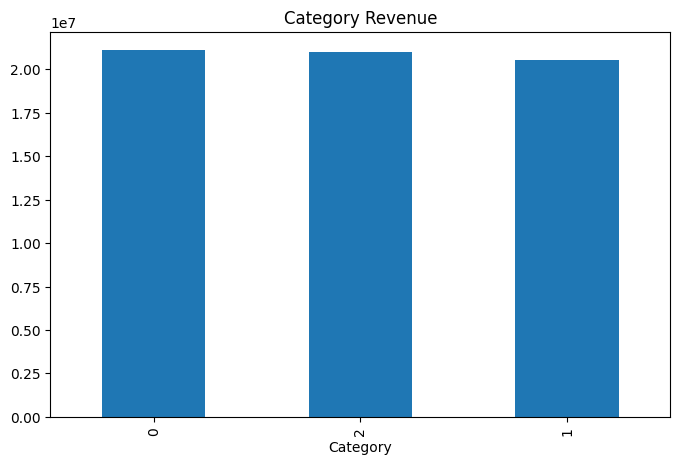

In [15]:
category_sales = (
    df.groupby("Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Category Revenue")

plt.show()

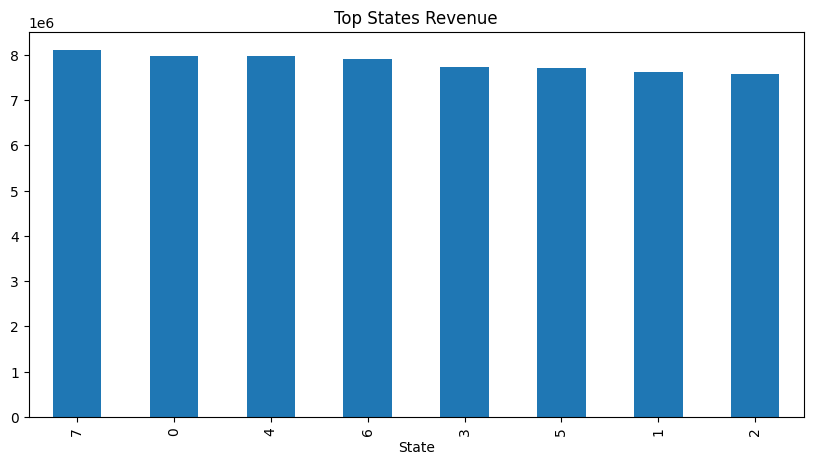

In [16]:
state_sales = (
    df.groupby("State")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

state_sales.head(10).plot(kind='bar')

plt.title("Top States Revenue")

plt.show()

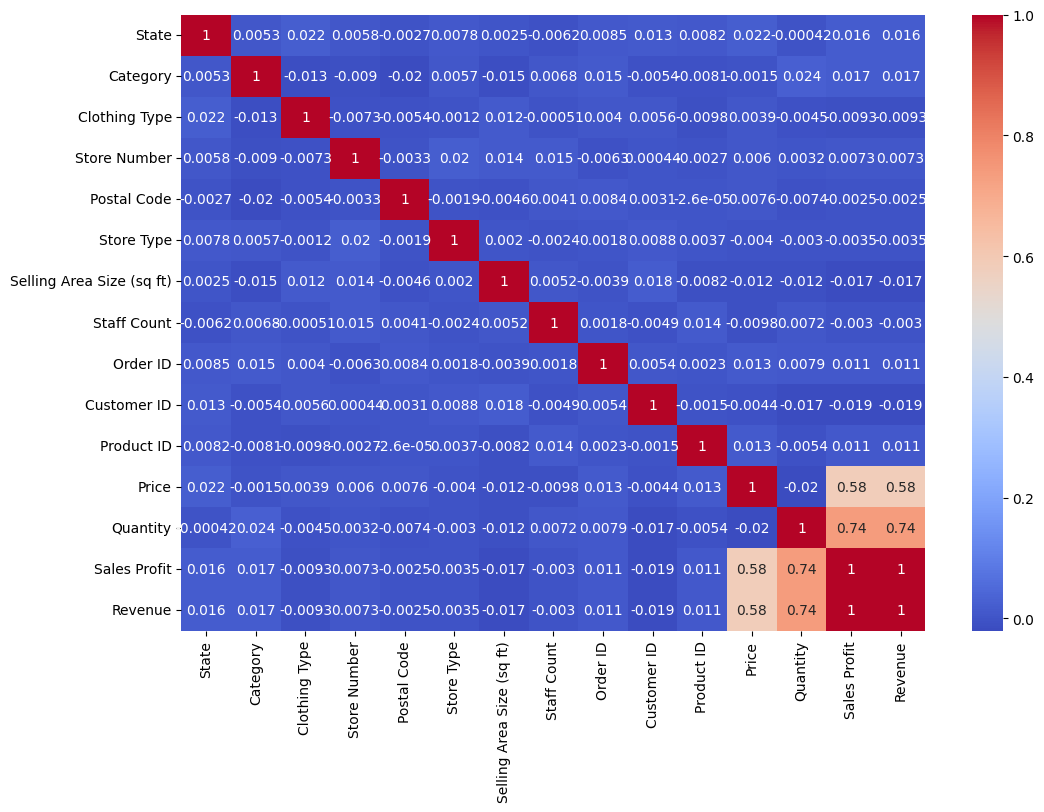

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [18]:
features = [
    "Price",
    "Quantity",
    "Category",
    "State",
    "Store Type",
    "Clothing Type",
    "Staff Count",
    "Selling Area Size (sq ft)"
]

X = df[features]

y = df["Revenue"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [21]:
y_pred = model.predict(X_test)

In [22]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 8.581727848101258
RMSE : 13.008084234161359
R2 Score : 0.9999940916370273


In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                     Feature    Importance
1                   Quantity  5.552177e-01
0                      Price  4.447684e-01
5              Clothing Type  3.190626e-06
6                Staff Count  3.129043e-06
3                      State  2.589599e-06
7  Selling Area Size (sq ft)  2.589452e-06
2                   Category  1.493787e-06
4                 Store Type  8.427205e-07


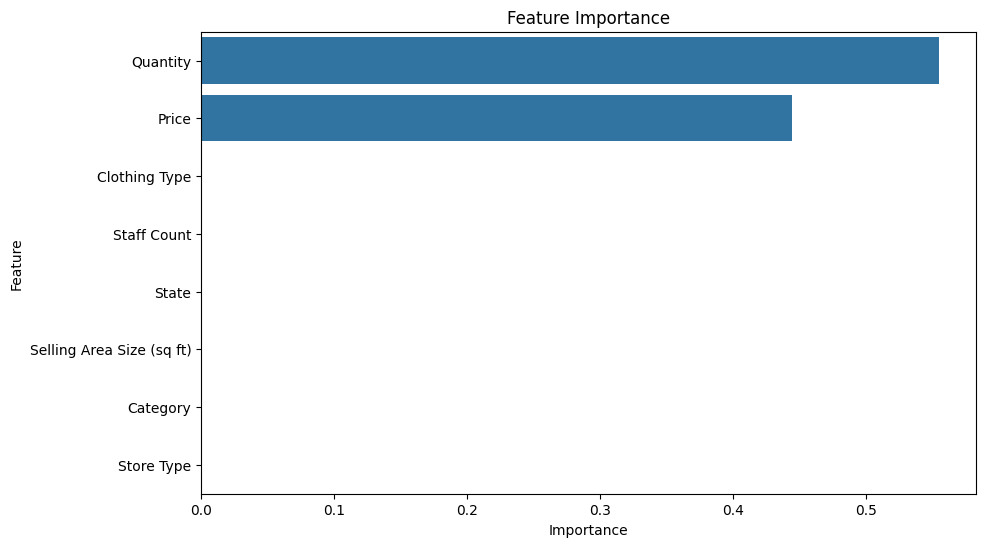

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [25]:
import pickle

pickle.dump(
    model,
    open("zudio_sales_model.pkl", "wb")
)